## **1. INSTALL LIBRARIES**

In [ ]:
!pip install optuna scikit-optimize shap
!pip install lightgbm --upgrade
!pip install xgboost --upgrade
!pip install catboost --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.4/247.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00


In [ ]:
# 📊 Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 📁 Google Colab Drive
from google.colab import drive

# ⚙️ System & Utilities
import os
import warnings
import joblib
from typing import Dict, List, Any, Optional, Union

# 📐 Math & Stats
import math
import numpy as np
import pandas as pd
from scipy.stats import uniform, randint
import optuna
import shap

# 🧠 Machine Learning
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score, log_loss
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    StackingClassifier, RandomForestClassifier, AdaBoostClassifier
)

# 🚀 Boosted Model
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import cuml
from cuml.ensemble import RandomForestClassifier as cuRF
import cudf
import cupy as cp

/usr/local/lib/python3.12/dist-packages/cudf/utils/gpu_utils.py:75: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))


In [ ]:
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


## **2. EDA AND CLEAN DATA**
- Load data:

In [ ]:
!unzip '/content/drive/MyDrive/Kaggle: Banking/playground-series-s5e8.zip'

Archive:  /content/drive/MyDrive/Kaggle: Banking/playground-series-s5e8.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
df_train = pd.read_csv('/content/train.csv', index_col = 'id')
df_test = pd.read_csv('/content/test.csv', index_col = 'id')
df_transform = pd.concat([df_train, df_test])
df_transform.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000000 entries, 0 to 999999
Data columns (total 17 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   age        1000000 non-null  int64  
 1   job        1000000 non-null  object 
 2   marital    1000000 non-null  object 
 3   education  1000000 non-null  object 
 4   default    1000000 non-null  object 
 5   balance    1000000 non-null  int64  
 6   housing    1000000 non-null  object 
 7   loan       1000000 non-null  object 
 8   contact    1000000 non-null  object 
 9   day        1000000 non-null  int64  
 10  month      1000000 non-null  object 
 11  duration   1000000 non-null  int64  
 12  campaign   1000000 non-null  int64  
 13  pdays      1000000 non-null  int64  
 14  previous   1000000 non-null  int64  
 15  poutcome   1000000 non-null  object 
 16  y          750000 non-null   float64
dtypes: float64(1), int64(7), object(9)
memory usage: 137.3+ MB


### **2.1. OVERVIEW ON DATA**
- Visualize other features:

In [ ]:
columns_to_plot = df_transform.columns.tolist()

# Create subplots
n_columns = len(columns_to_plot)
cols = 4
rows = math.ceil(n_columns / cols)
fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=[f'Distribution of {col}' for col in columns_to_plot],
    shared_yaxes=False ## Make y-axes independent for each subplot
)

# Iterate through each column and add its bar chart to a subplot
for i, col in enumerate(columns_to_plot):
    ## Calculate row and column index for the subplot
    row_index = math.floor(i / cols) + 1
    col_index = (i % cols) + 1

    ## Calculate value counts
    value_counts = df_transform[col].value_counts().reset_index()
    value_counts.columns = [col, 'count']

    ## Sort data for plotting
    if df_transform[col].dtype != 'object':
        value_counts = value_counts.sort_values(col)
    else:
        value_counts = value_counts.sort_values('count', ascending=False)
    bar_trace = go.Bar(x=value_counts[col], y=value_counts['count'], name=col)
    fig.add_trace(bar_trace, row=row_index, col=col_index)

# Plot graphs
fig.update_layout(
    title_text='Distribution of Features', showlegend=False
    height=rows * 300, width=cols * 300,
)
fig.show()

### **2.2. AGE CLUSTERING**
$$
\boxed{
\text{Visualize how }y \text{ value is contained in 4 age groups divided by} \texttt{ quantile } \text{ (statistical solution) and } \texttt{ KMeans } \text{ (ML solution).}
}
$$
- KMeans clustering

In [ ]:
# Applying KMeans to df_train
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
kmeans.fit(df_train['age'].to_numpy().reshape(-1, 1))
df_train['age_cluster'] = kmeans.predict(df_train['age'].to_numpy().reshape(-1, 1))

- Quantile clustering

In [ ]:
# Applying Quartile to df_train
age_quartiles = pd.qcut(df_train['age'], q=4, labels=['0', '1', '2', '3'])
df_train['age_quartile'] = age_quartiles

- Visualizing plots

In [ ]:
# KMeans: Bar chart
kmeans_cluster_centers = sorted(kmeans.cluster_centers_.flatten())
kmeans_counts = (
    df_train.groupby(['age', 'age_cluster'], observed=True)
    .size().reset_index(name='count')
    .astype({'age_cluster': 'str'})
)

# KMeans: Pie chart
kmeans_sunburst = (
    df_train.groupby(['age_cluster', 'y'], observed=True)
    .size().reset_index(name='count')
    .astype({'age_cluster': 'str', 'y': 'str'})
)

# Quartiles: Bar chart
quartile_counts = (
    df_train.groupby(['age', 'age_quartile'], observed=True)
    .size().reset_index(name='count')
    .astype({'age_quartile': 'str'})
)

# Quartiles: Pie chart
quartile_sunburst = (
    df_train.groupby(['age_quartile', 'y'], observed=True)
    .size().reset_index(name='count')
    .astype({'age_quartile': 'str', 'y': 'str'})
)

In [ ]:
# --- Create Subplots ---
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Age distribution by KMeans', 'Proportion of KMeans age and target y',
        'Age distribution by Quartile', 'Proportion of Quartiles age and target y'
    ),
    specs=[
        [{}, {'type':'domain'}],
        [{}, {'type':'domain'}]
    ],
    column_widths=[0.75, 0.25],
    vertical_spacing=0.1
)

# --- Add Traces to Subplots ---
y_color_map = {'0.0': 'blue', '1.0': 'red'}
  ## Top Left (Bar Chart): Age distribution by KMeans
bar_kmeans_fig = px.bar(kmeans_counts, x='age', y='count', color='age_cluster')

    ### Add traces with legendgroup and name
for trace in bar_kmeans_fig.data:
  category_value = trace.name
  fig.add_trace(trace, row=1, col=1)

    ### Add vertical lines for KMeans cluster centers
max_count = df_train['age'].value_counts().max()
for center in kmeans_cluster_centers:
  fig.add_trace(go.Scatter(
      x=[center, center], y=[0, max_count],
      mode='lines', line=dict(color='green', dash='dash'),
      showlegend=False, hoverinfo='text', hovertext=f'Cluster Center: {center:.2f}'
  ), row=1, col=1)

  ## Top Right (Sunburst Chart): Proportion of KMeans age group
sunburst_kmeans_fig = px.sunburst(kmeans_sunburst, path=['age_cluster', 'y'],
                                  values='count', color='y')
for trace in sunburst_kmeans_fig.data:
  fig.add_trace(trace, row=1, col=2)

  ## Bottom Left (Bar Chart): Age distribution by Quartile
bar_quartile_fig = px.bar(quartile_counts, x='age', y='count', color='age_quartile')

    ### Add traces with legendgroup and name
for trace in bar_quartile_fig.data:
  category_value = trace.name
  fig.add_trace(trace, row=2, col=1)

  ## Bottom Right (Sunburst Chart): Proportion of Quartiles age group
sunburst_quartile_fig = px.sunburst(quartile_sunburst, path=['age_quartile', 'y'],
                                    values='count', color='y')
for trace in sunburst_quartile_fig.data:
  fig.add_trace(trace, row=2, col=2)

# --- Update Layout ---
fig.update_layout(
    xaxis={'title': 'Age'}, yaxis={'title': 'Count'},
    xaxis2={'title': 'Age'}, yaxis2={'title': 'Count'},
    showlegend=False, height=900
)
fig.show()

- **KMeans clustering:** Imbalanced group between clusters (1, 2, 3, 4) shows the proportion of $y$ value is equally distributed (small age group contain small proportion of $y = 1$ and vice versa).
- **Quartiles clustering:** Balanced group between quartiles (Q1, Q2, Q3, Q4) shows the proportion of $y$ value is inequally distributed (equal age group contain different proportion of $y = 1$ and vice versa).

Our target value is $y$, therefore I opt for `KMeans` to classify age group.

In [ ]:
# Applying KMeans to df_transform
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
kmeans.fit(df_transform['age'].to_numpy().reshape(-1, 1))
df_transform['age'] = kmeans.predict(df_transform['age'].to_numpy().reshape(-1, 1))

### **2.3. NUMBER MAPPING**
$$
\boxed{
\text{Convert binary data } {yes/no} \text{ into } {0/1}
}
$$

In [ ]:
binary_cols = ['default', 'housing', 'loan']
df_transform['contact'] = df_transform['contact'].map({'cellular': 1, 'telephone': 1, 'unknown': 0})
df_transform['poutcome'] = df_transform['poutcome'].map({'success': 1, 'other': 0, 'failure': -1, 'unknown': 0})
for col in binary_cols:
  df_transform[col] = df_transform[col].map({'yes': 1, 'no': -1, 'unknown': 0})

$$
\boxed{
\text{Caculate logit } \texttt{OR} \text{ on default, housing and loan}
}
$$
- Since columns `default`, `housing`, `loan` relate to loan so I will merge two of them into `loan`.

In [ ]:
df_transform['loan'] = (((df_transform['housing'] == 1) | (df_transform['loan'] == 1)) | (df_transform['default'] == 1)).astype(int)
df_transform.drop(columns=['default', 'housing'], inplace=True)

$$
\boxed{
\text{Caculate average duration in seconds per each contact}
}
$$

In [ ]:
# Notice: handling division by zero
df_transform['duration_per_contact'] = (df_transform['duration'] / (df_transform['campaign'] + df_transform['previous'])).replace([np.inf, -np.inf], 0)
df_transform.drop(columns=['campaign', 'previous', 'duration'], inplace=True)

$$
\boxed{
\text{Convert education levels into number according the ascending levels}
}
$$

In [ ]:
education_mapping = {'primary': 1, 'secondary': 2, 'tertiary': 3, 'unknown': 0}
df_transform['education'] = df_transform['education'].map(education_mapping)

$$
\boxed{
\text{Divide days in a month into 3 phases by using quantile}
}
$$

In [ ]:
df_transform['day_category'] = pd.qcut(df_transform['day'], q=3, labels=['early', 'mid', 'late'])
df_transform['day_month'] = df_transform['day_category'].astype(str) + '_' + df_transform['month']
df_transform.drop(columns=['day', 'month', 'day_category'], inplace=True)

$$
\boxed{
\text{Using Pipeline for OHE and Scaler}
}
$$
- `marital`: one hot encoding
- `balance`: standard scaler
- `pdays`: standard scaler
- `duration_per_contact`: standard scaler
- `job_education`: one hot encoding
- `day_month`: one hot encoding

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ['marital', 'job', 'day_month'] ## One hot encoding
numerical_cols = ['balance', 'pdays', 'duration_per_contact'] ## Standard scaler

# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols),
    ],
    remainder='passthrough' ## Keep the remaining columns
)

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor)
])

# Fit and transform the data
df_transformed_processed = pipeline.fit_transform(df_transform).toarray()
cat_feature_names = pipeline.named_steps['preprocessing'].named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()

num_feature_names = numerical_cols
remainder_feature_names = [col for col in df_transform.columns if col not in categorical_cols + numerical_cols]
feature_names = cat_feature_names + num_feature_names + remainder_feature_names

# Convert the transformed data back to a pandas DataFrame
df_transform = pd.DataFrame(df_transformed_processed, columns=feature_names, index=df_transform.index)

,marital_divorced,marital_married,marital_single,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,day_month_mid_sep,balance,pdays,duration_per_contact,age,education,loan,contact,poutcome,y
id,,,,,,,,,,,,,,,,,,,,,
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.424996,-0.302769,-0.569388,2.0,2.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.244745,-0.302769,0.179770,2.0,2.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.213459,-0.302769,-0.484723,2.0,2.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.415397,-0.302769,-0.743850,1.0,2.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.111424,-0.302769,3.858852,1.0,2.0,1.0,1.0,0.0,1.0


- Here is the final `df_transform` which is the input for the `StackingModel`.

In [ ]:
df_transform.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   marital_divorced      1000000 non-null  float64
 1   marital_married       1000000 non-null  float64
 2   marital_single        1000000 non-null  float64
 3   job_admin.            1000000 non-null  float64
 4   job_blue-collar       1000000 non-null  float64
 5   job_entrepreneur      1000000 non-null  float64
 6   job_housemaid         1000000 non-null  float64
 7   job_management        1000000 non-null  float64
 8   job_retired           1000000 non-null  float64
 9   job_self-employed     1000000 non-null  float64
 10  job_services          1000000 non-null  float64
 11  job_student           1000000 non-null  float64
 12  job_technician        1000000 non-null  float64
 13  job_unemployed        1000000 non-null  float64
 14  job_unknown           1000000 non-null  

$$
\boxed{
\text{Visualize how data fields affect y value}
}
$$

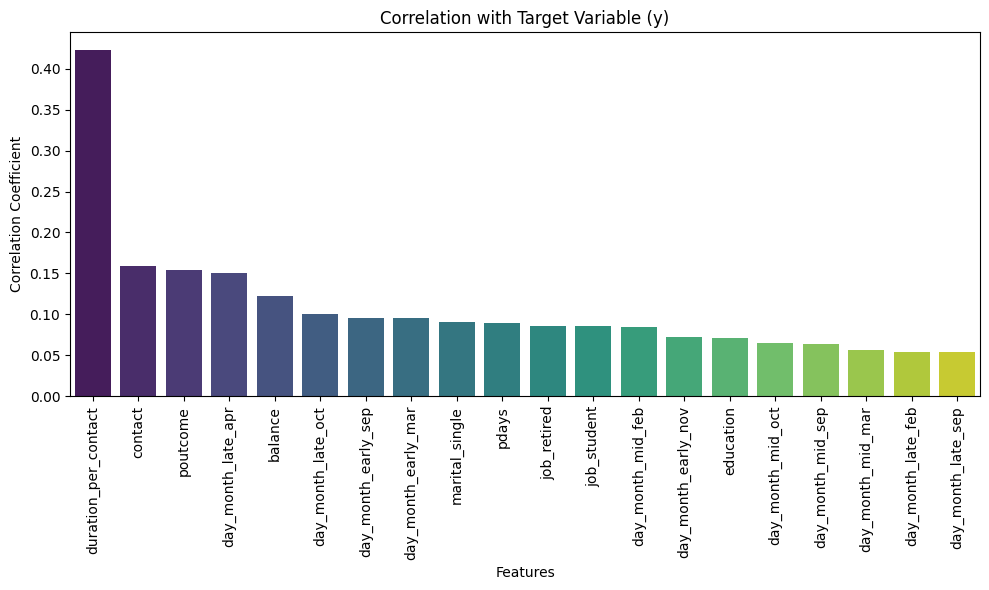

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df_transform.corr()
correlation_with_y = correlation_matrix['y'].sort_values(ascending=False)
correlation_with_y = correlation_with_y.drop('y').iloc[:20] ## show the 20 most affected columns

# Plot the correlations with 'y'
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_y.index, y=correlation_with_y.values,
            hue=correlation_with_y.index, legend=False
)

plt.xticks(rotation=90)
plt.title('Correlation with Target Variable y')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

- Save the data for further usage

In [ ]:
df_transform.to_csv('/content/data_v4.csv')

## **3. TRAINING MODEL**

- Write a class `StackingModel` to train a stacking model type with structure:
```
class StackingModel()
 ├──  __init__()
 |      Initialize StackingModel
 ├──  add_base_estimators()
 |      Add base estimators to the stacking model
 ├──  fit()
 |      Fit the stacking model
 ├──  load_model()
 |      Load a trained model
 ├──  optuna_search()
 |      Perform Optuna hyperparameter optimization
 ├──  plot_log()
 |      Plot comprehensive evaluation metrics
 ├──  predict()
 |      Predict class labels
 ├──  predict_proba()
 |      Predict class probabilities
 ├──  save_model()
 |      Save the trained model
 ```

In [ ]:
warnings.filterwarnings('ignore')
from sklearn.model_selection import learning_curve
from sklearn.metrics import ConfusionMatrixDisplay
class StackingModel(BaseEstimator, ClassifierMixin):
    """
    Advanced Stacking Model with GPU support, Optuna optimization, and comprehensive evaluation.
    Features:
    - GPU acceleration for all base estimators
    - Optuna hyperparameter optimization
    - Meta-feature generation
    - Comprehensive plotting and evaluation
    - Model persistence
    """

    def __init__(self, n_splits: int = 5, random_state: int = 42,
                 device: str = 'cuda', n_jobs: int = -1,
                 meta_learner: str = 'logistic_regression'):
        """
        Initialize StackingModel
        Args:
            n_splits: Number of folds for cross-validation
            random_state: Random seed for reproducibility
            device: Device to use ('cuda' or 'cpu')
            n_jobs: Number of parallel jobs
            meta_learner: Type of meta learner ('logistic_regression', 'xgb)
        """
        self.n_splits = n_splits
        self.random_state = random_state
        self.device = device
        self.n_jobs = n_jobs
        self.meta_learner = meta_learner

        self.base_estimators = {}
        self.trained_base_estimators = {}
        self.meta_features_train = None
        self.meta_learner_model = None
        self.label_encoder = None
        self.is_fitted = False
        self.history = {
            'optuna_trials': {},
            'training_metrics': {},
            'validation_metrics': {}
        }

    def add_base_estimators(self, estimators: Dict[str, Any]) -> None:
        """
        Add base estimators to the stacking model
        Args:
            estimators: Dictionary with estimator names as keys and
                       (estimator_instance, param_space) as values
        """
        for name, (estimator, param_space) in estimators.items():
            self.base_estimators[name] = {
                'estimator': estimator,
                'param_space': param_space,
                'best_params': None
            }

    def _get_gpu_params(self, estimator_name: str) -> Dict[str, Any]:
        """Get GPU-specific parameters for each estimator"""
        gpu_params = {}

        if self.device == 'cuda':
            if 'xgboost' in estimator_name.lower():
                gpu_params.update({'device': 'cuda', 'predictor': 'gpu_predictor'})
            elif 'lightgbm' in estimator_name.lower():
                gpu_params.update({'device': 'gpu'})
            elif 'catboost' in estimator_name.lower():
                gpu_params.update({'task_type': 'GPU', 'devices': '0'})
            elif 'randomforest' in estimator_name.lower():
                ## RAPIDS RF not require  device param
                pass
            elif 'logisticregression' in estimator_name.lower() and self.meta_learner == 'logistic_regression':
                gpu_params.update({})

        return gpu_params

    def optuna_search(self, X: pd.DataFrame, y: pd.Series,
                     estimator_name: str, n_trials: int = 3,
                     cv: int = 5, scoring: str = 'roc_auc') -> Any:
        """
        Perform Optuna hyperparameter optimization
        Args:
            X: Training features
            y: Training target
            estimator_name: Name of estimator to optimize
            n_trials: Number of Optuna trials
            cv: Cross-validation folds
            scoring: Scoring metric
        Returns:
            Best estimator with optimized parameters
        """
        if estimator_name not in self.base_estimators:
            raise ValueError(f"Estimator '{estimator_name}' not found")

        estimator_info = self.base_estimators[estimator_name]
        estimator = estimator_info['estimator']
        param_space = estimator_info['param_space']

        # Ensure binary classification
        if len(np.unique(y)) > 2:
            raise ValueError("Only binary classification is supported")

        # Perform a single train/validation split outside the objective for Optuna evaluation
        X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
            X, y, test_size=1/cv, random_state=self.random_state, stratify=y
        )

        # Determine if the estimator is a cuML estimator
        is_cuml_estimator = False
        if self.device == 'cuda':
            if 'randomforest' in estimator_name.lower(): # Check for cuML RandomForest
                is_cuml_estimator = True
        # RAPIDS -> cudf DataFrames/Series
        if self.device == 'cuda' and is_cuml_estimator:
            X_train_opt_gpu = cudf.DataFrame.from_pandas(X_train_opt)
            X_val_opt_gpu = cudf.DataFrame.from_pandas(X_val_opt)
            y_train_opt_gpu = cudf.Series(y_train_opt.values)
            y_val_opt_gpu = cudf.Series(y_val_opt.values)
        # non-RAPIDS -> pandas DataFrames
        else:
            X_train_opt_gpu = X_train_opt
            X_val_opt_gpu = X_val_opt
            y_train_opt_gpu = y_train_opt
            y_val_opt_gpu = y_val_opt

        def objective(trial):
            params = {}

            # Build parameters from param_space
            for param_name, param_config in param_space.items():
                if param_config['type'] == 'int':
                    params[param_name] = trial.suggest_int(
                        param_name, param_config['low'], param_config['high']
                    )
                elif param_config['type'] == 'float':
                    params[param_name] = trial.suggest_float(
                        param_name, param_config['low'], param_config['high'],
                        log=param_config.get('log', False)
                    )
                elif param_config['type'] == 'categorical':
                    params[param_name] = trial.suggest_categorical(
                        param_name, param_config['choices']
                    )

            # Add GPU parameters if applicable
            params.update(self._get_gpu_params(estimator_name))
            params['random_state'] = self.random_state

            # Create estimator with trial parameters, conditionally using cuML or scikit-learn
            if self.device == 'cuda' and 'randomforest' in estimator_name.lower():
                 model = cuRF(**params)
            elif 'xgboost' in estimator_name.lower():
                model = XGBClassifier(**params)
            elif 'lightgbm' in estimator_name.lower():
                model = LGBMClassifier(**params, verbosity=-1)
            elif 'catboost' in estimator_name.lower():
                model = CatBoostClassifier(**params, verbose=0)
            elif 'adaboost' in estimator_name.lower():
                model = AdaBoostClassifier(**params)
            elif 'randomforest' in estimator_name.lower():
                model = RandomForestClassifier(**params)
            else:
                 raise ValueError(f"Unknown estimator type for {estimator_name}")

            # Check if a cuml estimator
            is_cuml_estimator = isinstance(model, (cuml.ensemble.RandomForestClassifier,))

            # Convert data to numpy for non-cuml estimators
            if not is_cuml_estimator and self.device == 'cuda':
                X_train_fit = X_train_opt_gpu.to_numpy() if isinstance(X_train_opt_gpu, cudf.DataFrame) else X_train_opt_gpu
                y_train_fit = y_train_opt_gpu.to_numpy() if isinstance(y_train_opt_gpu, cudf.Series) else y_train_opt_gpu
                X_val_predict = X_val_opt_gpu.to_numpy() if isinstance(X_val_opt_gpu, cudf.DataFrame) else X_val_opt_gpu
            else:
                X_train_fit = X_train_opt_gpu
                y_train_fit = y_train_opt_gpu
                X_val_predict = X_val_opt_gpu

            # Fit and evaluate on the pre-split data
            model.fit(X_train_fit, y_train_fit)

            # Predict probabilities and convert to numpy immediately if needed
            val_proba_all = model.predict_proba(X_val_predict)
            if isinstance(val_proba_all, (cudf.Series, cudf.DataFrame, cp.ndarray)): # Added cp.ndarray for cuML output
                val_proba_all = val_proba_all.to_numpy() if hasattr(val_proba_all, 'to_numpy') else cp.asnumpy(val_proba_all) # Convert cp.ndarray to numpy

            if scoring == 'roc_auc':
                val_proba = val_proba_all[:, 1]
                score = roc_auc_score(y_val_opt.to_numpy(), val_proba)
            elif scoring == 'accuracy':
                val_pred = model.predict(X_val_predict)
                if isinstance(val_pred, (cudf.Series, cudf.DataFrame, cp.ndarray)): # Added cp.ndarray
                    val_pred = val_pred.to_numpy() if hasattr(val_pred, 'to_numpy') else cp.asnumpy(val_pred) # Convert cp.ndarray to numpy
                score = accuracy_score(y_val_opt.to_numpy(), val_pred)
            elif scoring == 'f1':
                val_pred = model.predict(X_val_predict)
                if isinstance(val_pred, (cudf.Series, cudf.DataFrame, cp.ndarray)): # Added cp.ndarray
                    val_pred = val_pred.to_numpy() if hasattr(val_pred, 'to_numpy') else cp.asnumpy(val_pred) # Convert cp.ndarray to numpy
                score = f1_score(y_val_opt.to_numpy(), val_pred)
            elif scoring == 'log_loss':
                score = log_loss(y_val_opt.to_numpy(), val_proba_all)
            return score

        # Run Optuna optimization
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

        # Store results
        self.history['optuna_trials'][estimator_name] = {
            'best_params': study.best_params,
            'best_score': study.best_value,
            'trials': len(study.trials)
        }

        # Load best parameters to models
        best_params = study.best_params.copy()
        best_params.update(self._get_gpu_params(estimator_name))
        best_params['random_state'] = self.random_state

        if self.device == 'cuda' and 'randomforest' in estimator_name.lower():
            best_estimator = cuRF(**best_params)
        elif 'xgboost' in estimator_name.lower():
            best_estimator = XGBClassifier(**best_params)
        elif 'lightgbm' in estimator_name.lower():
            best_estimator = LGBMClassifier(**best_params, verbosity=-1)
        elif 'catboost' in estimator_name.lower():
            best_estimator = CatBoostClassifier(**best_params, verbose=0)
        elif 'adaboost' in estimator_name.lower():
            best_estimator = AdaBoostClassifier(**best_params)
        elif 'randomforest' in estimator_name.lower():
             best_estimator = RandomForestClassifier(**best_params)

        self.base_estimators[estimator_name]['best_params'] = best_params
        self.base_estimators[estimator_name]['estimator'] = best_estimator

        return best_estimator

    def _generate_meta_feature(self, X: pd.DataFrame, y: pd.Series = None,
                              is_training: bool = True) -> np.ndarray:
        """
        Generate meta-features using out-of-fold predictions
        Args:
            X: Features
            y: Target (required for training)
            is_training: Whether this is for training
        Returns:
            Meta-features array (numpy array)
        """
        n_samples = X.shape[0]
        n_estimators = len(self.base_estimators)
        meta_features = np.zeros((n_samples, n_estimators))

        if is_training:
            if y is None:
                 raise ValueError("y is required for training meta-features")

            skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True,
                                random_state=self.random_state)

            # Convert full training dataset to cudf if device='cuda'
            use_cuml_in_base = any(isinstance(info['estimator'], (cuml.ensemble.RandomForestClassifier,))
                                  for info in self.base_estimators.values())
            if self.device == 'cuda' and use_cuml_in_base:
                X_gpu_full = cudf.DataFrame.from_pandas(X)
                y_gpu_full = cudf.Series(y.values)
            else:
                X_gpu_full = X
                y_gpu_full = y

            for i, (name, info) in enumerate(self.base_estimators.items()):
                estimator = info['estimator']
                oof_preds = np.zeros(n_samples)

                # Check if a cuml estimator
                is_cuml_estimator = isinstance(estimator, (cuml.ensemble.RandomForestClassifier,))

                for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)): # Split using original pandas DataFrames
                    # Select data for the fold from the appropriate DataFrame type
                    if self.device == 'cuda' and use_cuml_in_base:
                        X_train_fold = X_gpu_full.iloc[train_idx]
                        X_val_fold = X_gpu_full.iloc[val_idx]
                        y_train_fold = y_gpu_full.iloc[train_idx]
                    else:
                        X_train_fold, X_val_fold = X_gpu_full.iloc[train_idx], X_gpu_full.iloc[val_idx]
                        y_train_fold, y_val_fold = y_gpu_full.iloc[train_idx], y_gpu_full.iloc[val_idx]

                    # Convert data to numpy for non-cuml estimators
                    if not is_cuml_estimator and self.device == 'cuda':
                        X_train_fit = X_train_fold.to_numpy() if isinstance(X_train_fold, cudf.DataFrame) else X_train_fold
                        y_train_fit = y_train_fold.to_numpy() if isinstance(y_train_fold, cudf.Series) else y_train_fold
                        X_val_predict = X_val_fold.to_numpy() if isinstance(X_val_fold, cudf.DataFrame) else X_val_fold
                    else:
                        X_train_fit = X_train_fold
                        y_train_fit = y_train_fold
                        X_val_predict = X_val_fold

                    # Fit the estimator
                    estimator.fit(X_train_fit, y_train_fit)

                    # Predict probabilities and convert back to numpy if needed for meta-features
                    val_preds_all = estimator.predict_proba(X_val_predict)
                    if isinstance(val_preds_all, (cudf.Series, cudf.DataFrame, cp.ndarray)): # Added cp.ndarray for cuML output
                        val_preds_all = val_preds_all.to_numpy() if hasattr(val_preds_all, 'to_numpy') else cp.asnumpy(val_preds_all) # Convert cp.ndarray to numpy

                    # Select probability of the positive class
                    val_preds = val_preds_all[:, 1]
                    meta_features[val_idx, i] = val_preds

                # Store the last trained estimator on the full training data (for prediction)
                if self.device == 'cuda' and not is_cuml_estimator:
                    ## Convert to numpy for non-cuml estimators
                    X_full_np = X_gpu_full.to_numpy() if isinstance(X_gpu_full, cudf.DataFrame) else X_gpu_full
                    y_full_np = y_gpu_full.to_numpy() if isinstance(y_gpu_full, cudf.Series) else y_gpu_full
                    estimator.fit(X_full_np, y_full_np)
                else:
                    estimator.fit(X_gpu_full, y_gpu_full)

                self.trained_base_estimators[name] = estimator

        else:
            X_pred_data = X

            # Convert input data to cudf if device is cuda and any base estimator is cuML
            use_cuml_in_base = any(isinstance(info['estimator'], (cuml.ensemble.RandomForestClassifier,))
                                  for info in self.base_estimators.values())
            if self.device == 'cuda' and use_cuml_in_base:
                X_pred_data_gpu = cudf.DataFrame.from_pandas(X_pred_data)
            else:
                X_pred_data_gpu = X_pred_data

            for i, (name, info) in enumerate(self.base_estimators.items()):
                estimator = self.trained_base_estimators.get(name)
                if estimator is None:
                    raise ValueError(f"Base estimator '{name}' not trained. Call fit() first.")

                # Determine if the current estimator is a cuml estimator
                is_cuml_estimator = isinstance(estimator, (cuml.ensemble.RandomForestClassifier,))

                # Convert to numpy for non-cuml estimators before predicting if on GPU
                if not is_cuml_estimator and self.device == 'cuda':
                    X_predict_np = X_pred_data_gpu.to_numpy() if isinstance(X_pred_data_gpu, cudf.DataFrame) else X_pred_data_gpu
                else:
                    X_predict_np = X_pred_data_gpu

                # Predict probabilities and convert back to numpy if needed for meta-features
                test_preds_all = estimator.predict_proba(X_predict_np)
                if isinstance(test_preds_all, (cudf.Series, cudf.DataFrame, cp.ndarray)): # Added cp.ndarray
                    test_preds_all = test_preds_all.to_numpy() if hasattr(test_preds_all, 'to_numpy') else cp.asnumpy(test_preds_all) # Convert cp.ndarray to numpy
                test_preds = test_preds_all[:, 1]
                meta_features[:, i] = test_preds

        # Meta-features are returned as numpy arrays
        return meta_features

    def fit(self, X: pd.DataFrame, y: pd.Series,
            X_val: Optional[pd.DataFrame] = None,
            y_val: Optional[pd.Series] = None) -> 'StackingModel':
        """
        Fit the stacking model
        Args:
            X: Training features
            y: Training target
            X_val: Validation features (optional)
            y_val: Validation target (optional)
        Returns:
            self
        """
        # Handle label encoding for non-numeric targets
        if y.dtype == 'object':
            self.label_encoder = LabelEncoder()
            y_encoded = self.label_encoder.fit_transform(y)
        else:
            y_encoded = y

        # Generate meta-features
        print("Generating meta-features...")
        self.meta_features_train = self._generate_meta_feature(X, y_encoded, is_training=True)

        # Train meta-learner
        print("Training meta-learner...")
        if self.meta_learner == 'logistic_regression':
            if self.device == 'cuda':
                self.meta_learner_model = cuml.linear_model.LogisticRegression(
                    max_iter=1000
                )
                # Convert meta_features_train to cudf for cuML Logistic Regression
                meta_features_train_fit = cudf.DataFrame(self.meta_features_train)
                y_encoded_fit = cudf.Series(y_encoded)
            else:
                self.meta_learner_model = LogisticRegression(
                    random_state=self.random_state,
                    max_iter=1000
                )
                # Use numpy arrays for scikit-learn Logistic Regression
                meta_features_train_fit = self.meta_features_train
                y_encoded_fit = y_encoded

        elif self.meta_learner == 'xgb':
            self.meta_learner_model = XGBClassifier(
                random_state=self.random_state,
                **self._get_gpu_params('xgboost')
            )
            meta_features_train_fit = self.meta_features_train
            y_encoded_fit = y_encoded
        elif self.meta_learner == 'lgb':
            self.meta_learner_model = LGBMClassifier(
                random_state=self.random_state, verbosity=-1,
                **self._get_gpu_params('lightgbm')
            )
            meta_features_train_fit = self.meta_features_train
            y_encoded_fit = y_encoded

        # Fit the meta-learner
        self.meta_learner_model.fit(meta_features_train_fit, y_encoded_fit)
        self.is_fitted = True # Set is_fitted to True after meta-learner is fitted

        # Validation metrics if provided
        if X_val is not None and y_val is not None:
            val_pred = self.predict(X_val)
            val_proba = self.predict_proba(X_val)

            # Ensure y_val is numpy for scikit-learn scoring
            if isinstance(y_val, (cudf.Series, cudf.DataFrame)):
                y_val_np = y_val.to_numpy()
            else:
                y_val_np = y_val

            # Ensure val_pred and val_proba are numpy for scikit-learn scoring
            if isinstance(val_pred, (cudf.Series, cudf.DataFrame)):
                val_pred_np = val_pred.to_numpy()
            else:
                val_pred_np = val_pred

            if isinstance(val_proba, (cudf.Series, cudf.DataFrame)):
                val_proba_np = val_proba.to_numpy()
            else:
                val_proba_np = val_proba

            self.history['validation_metrics'] = {
                'accuracy': accuracy_score(y_val_np, val_pred_np),
                'roc_auc': roc_auc_score(y_val_np, val_proba_np[:, 1]),
                'f1': f1_score(y_val_np, val_pred_np),
                'precision': precision_score(y_val_np, val_pred_np),
                'recall': recall_score(y_val_np, val_pred_np),
                'log_loss': log_loss(y_val_np, val_proba_np)
            }

        print("Stacking model training completed!")
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """
        Predict class probabilities
        Args:
            X: Features to predict
        Returns:
            Probability array (numpy array)
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")

        # Generate meta-features (handles potential cudf internally, returns numpy)
        meta_features = self._generate_meta_feature(X, is_training=False)

        # Convert meta-features to cudf if meta-learner is cuML Logistic Regression
        if self.device == 'cuda' and self.meta_learner == 'logistic_regression':
             meta_features_predict = cudf.DataFrame(meta_features)
        else:
             meta_features_predict = meta_features # Meta-learner predicts on numpy meta-features

        # Meta-learner predicts
        proba = self.meta_learner_model.predict_proba(meta_features_predict)

        # Convert cuML output to numpy if necessary
        if isinstance(proba, (cudf.Series, cudf.DataFrame, cp.ndarray)):
             proba = proba.to_numpy() if hasattr(proba, 'to_numpy') else cp.asnumpy(proba)

        return proba

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """
        Predict class labels
        Args:
            X: Features to predict
        Returns:
            Predicted labels (numpy array)
        """
        proba = self.predict_proba(X) # predict_proba now always returns numpy
        if self.label_encoder:
            return self.label_encoder.inverse_transform(proba.argmax(axis=1))
        return proba.argmax(axis=1)

    def plot_log(self, X_test: pd.DataFrame, y_test: pd.Series,
                 save_path: str = 'plots', prefix: str = 'stacking_model') -> None:
        """
        Plot comprehensive evaluation metrics including correlation of meta-features and SHAP summary.
        Args:
            X_test: Test features
            y_test: Test target
            save_path: Directory to save plots
            prefix: Prefix for plot filenames
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")

        os.makedirs(save_path, exist_ok=True)

        # Predictions (will be numpy arrays)
        y_pred = self.predict(X_test)
        y_proba = self.predict_proba(X_test)

        # Ensure y_test is numpy for scikit-learn plotting functions
        if isinstance(y_test, (cudf.Series, cudf.DataFrame)):
             y_test_np = y_test.to_numpy()
        else:
             y_test_np = y_test

        # Classification report
        report = classification_report(y_test_np, y_pred, output_dict=True)

        # --- Generate meta-features for plotting ---
        X_test_meta = self._generate_meta_feature(X_test, is_training=False)
        feature_names = list(self.base_estimators.keys())
        X_test_meta_df = pd.DataFrame(X_test_meta, columns=feature_names, index=X_test.index)

        # --- Create Subplots for the first 5 plots ---
        fig, axes = plt.subplots(2, 3, figsize=(20, 12)) # 2 rows, 3 columns
        fig.suptitle(f'{prefix} - Model Evaluation and Meta-Feature Analysis', fontsize=16)

        # Flatten the axes array for easy iteration
        axes = axes.flatten()

        # 1. Confusion Matrix
        cm = confusion_matrix(y_test_np, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')

        # 2. Classification Report Heatmap
        report_df = pd.DataFrame(report).transpose()
        sns.heatmap(report_df.iloc[:-1, :-1], annot=True, fmt='.3f',
                   cmap='Blues', ax=axes[1])
        axes[1].set_title('Classification Report')

        # 3. ROC Curve (for binary classification)
        if len(np.unique(y_test_np)) == 2:
            from sklearn.metrics import roc_curve
            fpr, tpr, _ = roc_curve(y_test_np, y_proba[:, 1])
            auc = roc_auc_score(y_test_np, y_proba[:, 1])

            axes[2].plot(fpr, tpr, color='darkorange', lw=2,
                           label=f'ROC curve (AUC = {auc:.3f})')
            axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            axes[2].set_xlim([0.0, 1.0])
            axes[2].set_ylim([0.0, 1.05])
            axes[2].set_xlabel('False Positive Rate')
            axes[2].set_ylabel('True Positive Rate')
            axes[2].set_title('ROC Curve')
            axes[2].legend(loc="lower right")
        else:
            axes[2].text(0.5, 0.5, 'ROC Curve\n(Binary Classification Only)',
                           ha='center', va='center', transform=axes[2].transAxes)

        # 4. Feature Importance (if meta-learner supports it)
        try:
            importances = None
            if hasattr(self.meta_learner_model, 'feature_importances_'):
                importances = self.meta_learner_model.feature_importances_
            elif hasattr(self.meta_learner_model, 'coef_'):
                coef_values = self.meta_learner_model.coef_
                if isinstance(coef_values, (cudf.Series, cudf.DataFrame, cp.ndarray)):
                    coef_values = coef_values.to_numpy() if hasattr(coef_values, 'to_numpy') else cp.asnumpy(coef_values)
                elif isinstance(coef_values, pd.Series):
                    coef_values = coef_values.to_numpy()
                importances = np.abs(coef_values[0])

            if importances is not None:
                indices = np.argsort(importances)[::-1]
                axes[3].bar(range(len(importances)), importances[indices])
                axes[3].set_xticks(range(len(importances)))
                axes[3].set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
                axes[3].set_title('Meta-Learner Feature Importance')
                axes[3].set_ylabel('Importance')
            else:
                axes[3].text(0.5, 0.5, 'Feature Importance\n(Not Available)',
                               ha='center', va='center', transform=axes[3].transAxes)
        except Exception as e:
            axes[3].text(0.5, 0.5, f'Feature Importance\n(Error: {e})',
                           ha='center', va='center', transform=axes[3].transAxes)

        # 5. Correlation between Base Estimator Predictions (Meta-Features)
        meta_feature_corr = X_test_meta_df.corr()
        sns.heatmap(meta_feature_corr, annot=True, cmap='coolwarm', fmt=".2f",
                    linewidths=.5, ax=axes[4])
        axes[4].set_title('Correlation of Base Estimator Predictions')
        axes[4].set_xticklabels(meta_feature_corr.columns, rotation=45, ha='right')
        axes[4].set_yticklabels(meta_feature_corr.index, rotation=0)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to leave space for suptitle
        plt.savefig(os.path.join(save_path, f'{prefix}_evaluation.png'), dpi=300, bbox_inches='tight')
        plt.close()

        # --- Generate and save SHAP Summary Plot separately ---

        meta_learner = self.meta_learner_model

        # Determine the type of meta-learner and create the appropriate explainer
        if isinstance(meta_learner, (XGBClassifier, LGBMClassifier, CatBoostClassifier)):
            explainer = shap.TreeExplainer(meta_learner)
            shap_values = explainer.shap_values(X_test_meta_df)
        elif isinstance(meta_learner, (LogisticRegression, cuml.linear_model.LogisticRegression)):
            X_test_meta_np = X_test_meta

            # Use CPU-based dummy model for SHAP if cuML Logistic Regression is used
            if isinstance(meta_learner, cuml.linear_model.LogisticRegression):
                dummy_lr = LogisticRegression(random_state=self.random_state)
                dummy_lr.coef_ = meta_learner.coef_.to_numpy()
                dummy_lr.intercept_ = meta_learner.intercept_.to_numpy()
                explainer = shap.LinearExplainer(dummy_lr, X_test_meta_np) # Use numpy array here and dummy model
            else: # For scikit-learn Logistic Regression
                explainer = shap.LinearExplainer(meta_learner, X_test_meta_np) # Use numpy array here

            # Compute SHAP values using the numpy meta-features
            shap_values = explainer.shap_values(X_test_meta_np)

        else:
            print(f"SHAP explainer not supported for meta-learner type: {type(meta_learner)}")
            shap_values = None

        if shap_values is not None:
            plt.figure(figsize=(10, 6))
            # For binary classification, plot SHAP values for the positive class (class 1)
            if isinstance(shap_values, list) and len(shap_values) == 2:
                shap_values_plot = cp.asnumpy(shap_values[1]) if isinstance(shap_values[1], cp.ndarray) else shap_values[1]
                shap.summary_plot(shap_values_plot, X_test_meta_df, show=False)
                plt.title('SHAP Summary Plot')
            else:
                # Handle cases where shap_values might be a single array
                shap_values_plot = cp.asnumpy(shap_values) if isinstance(shap_values, cp.ndarray) else shap_values
                shap.summary_plot(shap_values_plot, X_test_meta_df, show=False)
                plt.title('SHAP Summary Plot')

            plt.tight_layout()
            plt.savefig(os.path.join(save_path, f'{prefix}_shap_summary.png'), dpi=300, bbox_inches='tight')
            plt.close()
            print(f"SHAP summary plot saved to {os.path.join(save_path, f'{prefix}_shap_summary.png')}")

        # Save metrics to file
        metrics = {
            'accuracy': accuracy_score(y_test_np, y_pred),
            'roc_auc': roc_auc_score(y_test_np, y_proba[:, 1]) if len(np.unique(y_test_np)) == 2 else None,
            'f1': f1_score(y_test_np, y_pred, average='weighted'),
            'precision': precision_score(y_test_np, y_pred, average='weighted'),
            'recall': recall_score(y_test_np, y_pred, average='weighted'),
            'log_loss': log_loss(y_test_np, y_proba)
        }

        with open(os.path.join(save_path, f'{prefix}_metrics.txt'), 'w') as f:
            for metric, value in metrics.items():
                if value is not None:
                    f.write(f"{metric}: {value:.4f}\n")

        print(f"Evaluation plots saved to {save_path}")

    def save_model(self, filepath: str) -> None:
        """Save the trained model"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")

        model_data = {
            'base_estimators': self.base_estimators,
            'trained_base_estimators': self.trained_base_estimators, # Storing trained estimators might be large
            'meta_learner_model': self.meta_learner_model,
            'label_encoder': self.label_encoder,
            'history': self.history,
            'params': {
                'n_splits': self.n_splits,
                'random_state': self.random_state,
                'device': self.device,
                'meta_learner': self.meta_learner
            }
        }

        joblib.dump(model_data, filepath)
        print(f"Model saved to {filepath}")

    def load_model(self, filepath: str) -> 'StackingModel':
        """Load a trained model"""
        model_data = joblib.load(filepath)

        self.base_estimators = model_data['base_estimators']
        self.trained_base_estimators = model_data['trained_base_estimators']
        self.meta_learner_model = model_data['meta_learner_model']
        self.label_encoder = model_data['label_encoder']
        self.history = model_data['history']

        params = model_data['params']
        self.n_splits = params['n_splits']
        self.random_state = params['random_state']
        self.device = params['device']
        self.meta_learner = params['meta_learner']

        self.is_fitted = True
        print(f"Model loaded from {filepath}")
        return self

- Load data for training:

In [ ]:
from sklearn.model_selection import train_test_split

df_transform = pd.read_csv('/content/data_v4.csv', index_col = 'id')
df_train = df_transform.loc[~np.isnan(df_transform['y'])]

X = df_train.drop('y', axis=1)
y = df_train['y']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

- Start training:

In [ ]:
# Define base estimators with parameter spaces
estimators = {
    'XGBoost': (
        XGBClassifier(),
        {
            'n_estimators': {'type': 'int', 'low': 100, 'high': 500},
            'learning_rate': {'type': 'float', 'low': 0.01, 'high': 0.3},
            'max_depth': {'type': 'int', 'low': 3, 'high': 10},
            'subsample': {'type': 'float', 'low': 0.6, 'high': 1.0},
            'colsample_bytree': {'type': 'float', 'low': 0.6, 'high': 1.0}
        }
    ),
    'LightGBM': (
        LGBMClassifier(),
        {
            'n_estimators': {'type': 'int', 'low': 100, 'high': 500},
            'learning_rate': {'type': 'float', 'low': 0.01, 'high': 0.3},
            'max_depth': {'type': 'int', 'low': 3, 'high': 10},
            'num_leaves': {'type': 'int', 'low': 20, 'high': 100},
            'subsample': {'type': 'float', 'low': 0.6, 'high': 1.0}
        }
    ),
    'AdaBoost': (
        AdaBoostClassifier(),
        {
            'n_estimators': {'type': 'int', 'low': 50, 'high': 500},
            'learning_rate': {'type': 'float', 'low': 0.01, 'high': 1.0},
        }
    )
}

# Initialize and train model
model = StackingModel(n_splits=5, random_state=42, device='cuda',
                      meta_learner='logistic_regression')
model.add_base_estimators(estimators)

# Run Optuna optimization for each estimator
for name in estimators.keys():
    print(f"\nOptimizing {name}...")
    model.optuna_search(X_train, y_train, name, n_trials=10)

# Fit the stacking model
print("\nTraining stacking model...")
model.fit(X_train, y_train, X_test, y_test)

# Plot results
model.plot_log(X_test, y_test)

# Save model
model.save_model('stacking_model.pkl')

print("\nTraining completed!")
print(f"Test Accuracy: {model.history['validation_metrics']['accuracy']:.4f}")
print(f"Test ROC-AUC: {model.history['validation_metrics']['roc_auc']:.4f}")


Optimizing XGBoost...


[I 2025-08-31 13:57:58,262] A new study created in memory with name: no-name-e001b197-2bca-4b68-aec3-b8ac9ef99bcb


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-08-31 13:58:03,073] Trial 0 finished with value: 0.9376899638172934 and parameters: {'n_estimators': 325, 'learning_rate': 0.08481451634579101, 'max_depth': 3, 'subsample': 0.6163790952679626, 'colsample_bytree': 0.7304941277086135}. Best is trial 0 with value: 0.9376899638172934.
[I 2025-08-31 13:58:06,670] Trial 1 finished with value: 0.9433646361104605 and parameters: {'n_estimators': 224, 'learning_rate': 0.21713528372127913, 'max_depth': 7, 'subsample': 0.8242613706114134, 'colsample_bytree': 0.6820743901683235}. Best is trial 1 with value: 0.9433646361104605.
[I 2025-08-31 13:58:10,289] Trial 2 finished with value: 0.9329540824466966 and parameters: {'n_estimators': 258, 'learning_rate': 0.015079771154472253, 'max_depth': 5, 'subsample': 0.6207396824386913, 'colsample_bytree': 0.8244439288459013}. Best is trial 1 with value: 0.9433646361104605.
[I 2025-08-31 13:58:15,535] Trial 3 finished with value: 0.9418551294833197 and parameters: {'n_estimators': 370, 'learning_rate'

[I 2025-08-31 13:58:42,503] A new study created in memory with name: no-name-0024b4c5-417d-4671-b8af-7729ef7dbd2f


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-08-31 13:58:57,177] Trial 0 finished with value: 0.9404688333330596 and parameters: {'n_estimators': 266, 'learning_rate': 0.07316801319977978, 'max_depth': 5, 'num_leaves': 81, 'subsample': 0.753685586361483}. Best is trial 0 with value: 0.9404688333330596.
[I 2025-08-31 13:59:14,235] Trial 1 finished with value: 0.9424806228910929 and parameters: {'n_estimators': 437, 'learning_rate': 0.23985856118088383, 'max_depth': 6, 'num_leaves': 91, 'subsample': 0.6773117822143017}. Best is trial 1 with value: 0.9424806228910929.
[I 2025-08-31 13:59:21,364] Trial 2 finished with value: 0.9414383979924599 and parameters: {'n_estimators': 214, 'learning_rate': 0.1860190635926458, 'max_depth': 4, 'num_leaves': 35, 'subsample': 0.9137318114552316}. Best is trial 1 with value: 0.9424806228910929.
[I 2025-08-31 13:59:31,572] Trial 3 finished with value: 0.941023149076421 and parameters: {'n_estimators': 201, 'learning_rate': 0.06455857661165758, 'max_depth': 7, 'num_leaves': 89, 'subsample': 

[I 2025-08-31 14:00:49,921] A new study created in memory with name: no-name-8b76aee5-bd94-4b59-9e49-94b8eb44448e


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-08-31 14:02:10,810] Trial 0 finished with value: 0.8969871203508474 and parameters: {'n_estimators': 169, 'learning_rate': 0.03450967820828933}. Best is trial 0 with value: 0.8969871203508474.
[I 2025-08-31 14:04:17,696] Trial 1 finished with value: 0.9195763761922555 and parameters: {'n_estimators': 272, 'learning_rate': 0.18059848637447332}. Best is trial 1 with value: 0.9195763761922555.
[I 2025-08-31 14:06:50,674] Trial 2 finished with value: 0.9186301599589706 and parameters: {'n_estimators': 329, 'learning_rate': 0.1319939821863095}. Best is trial 1 with value: 0.9195763761922555.
[I 2025-08-31 14:07:59,741] Trial 3 finished with value: 0.9209060975491712 and parameters: {'n_estimators': 148, 'learning_rate': 0.5048410138698619}. Best is trial 3 with value: 0.9209060975491712.
[I 2025-08-31 14:10:04,752] Trial 4 finished with value: 0.9174375257174368 and parameters: {'n_estimators': 262, 'learning_rate': 0.11942098176826327}. Best is trial 3 with value: 0.920906097549171

- Make predictions on `test_set`

In [ ]:
df_test = df_transform.loc[np.isnan(df_transform['y'])]
X_test = df_test.drop('y', axis=1)
y_pred = model.predict(X_test)
df_submission = pd.DataFrame({'id': df_test.index, 'y': y_pred})
df_submission.to_csv('submission.csv', index=False)

- Save logs

In [ ]:
!zip training_v4.zip plots/* data_v4.csv stacking_model.pkl submission.csv

updating: plots/stacking_model_evaluation.png (deflated 20%)
updating: plots/stacking_model_metrics.txt (deflated 20%)
updating: plots/stacking_model_shap_summary.png (deflated 9%)
updating: stacking_model.pkl (deflated 65%)
updating: submission.csv (deflated 74%)
  adding: data_v4.csv (deflated 89%)


## **4. ANALYSIS**
- Base on the `meta_feature` and `shap_summary, I conclude that `CatBoost` should be excluded for faster and more accurate `meta_feature`.
- According to the `correlation of base estimators` and `shap_summary`, I can see that lots of models give the same `meta_feature` for `meta_learner`. Therefore, I will use only `AdaBoost`, `LightGBM` and `XGBoost` for lighter stacking model.